# 0. DATA 불러오기
phase1에서 가공해두었던 데이터를 불러오기

In [10]:
import scanpy as sc

adata = sc.read_h5ad('../phase1_scrna/dataset/GSE127465_human_final.h5ad')
print(adata)
print(adata.obs['cell_type'].value_counts())


AnnData object with n_obs × n_vars = 44860 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'n_counts', 'sample', 'leiden', 'cell_type'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'cell_type_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'
cell_type
Unknown        14041
T cell         14036
Macrophage      9106
B cell          4597
Cancer cell     3080
Name: count, dt

In [11]:
print(adata.obs.columns.tolist())
print(adata.obs['cell_type'].value_counts())

['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'n_counts', 'sample', 'leiden', 'cell_type']
cell_type
Unknown        14041
T cell         14036
Macrophage      9106
B cell          4597
Cancer cell     3080
Name: count, dtype: int64


In [12]:
mac = adata[adata.obs['cell_type'] == 'Macrophage'].copy()
print(mac.shape)

(9106, 2000)


8


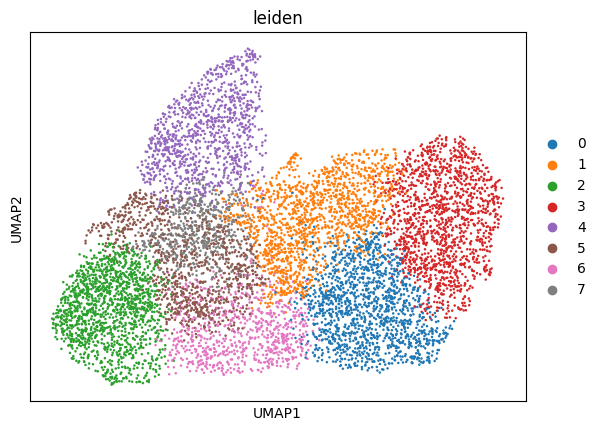

In [13]:
sc.pp.neighbors(mac, use_rep='X_pca_harmony', n_pcs=17)
sc.tl.umap(mac, random_state=42)
sc.tl.leiden(mac, resolution=0.5)
print(mac.obs['leiden'].nunique())
sc.pl.umap(mac, color='leiden')

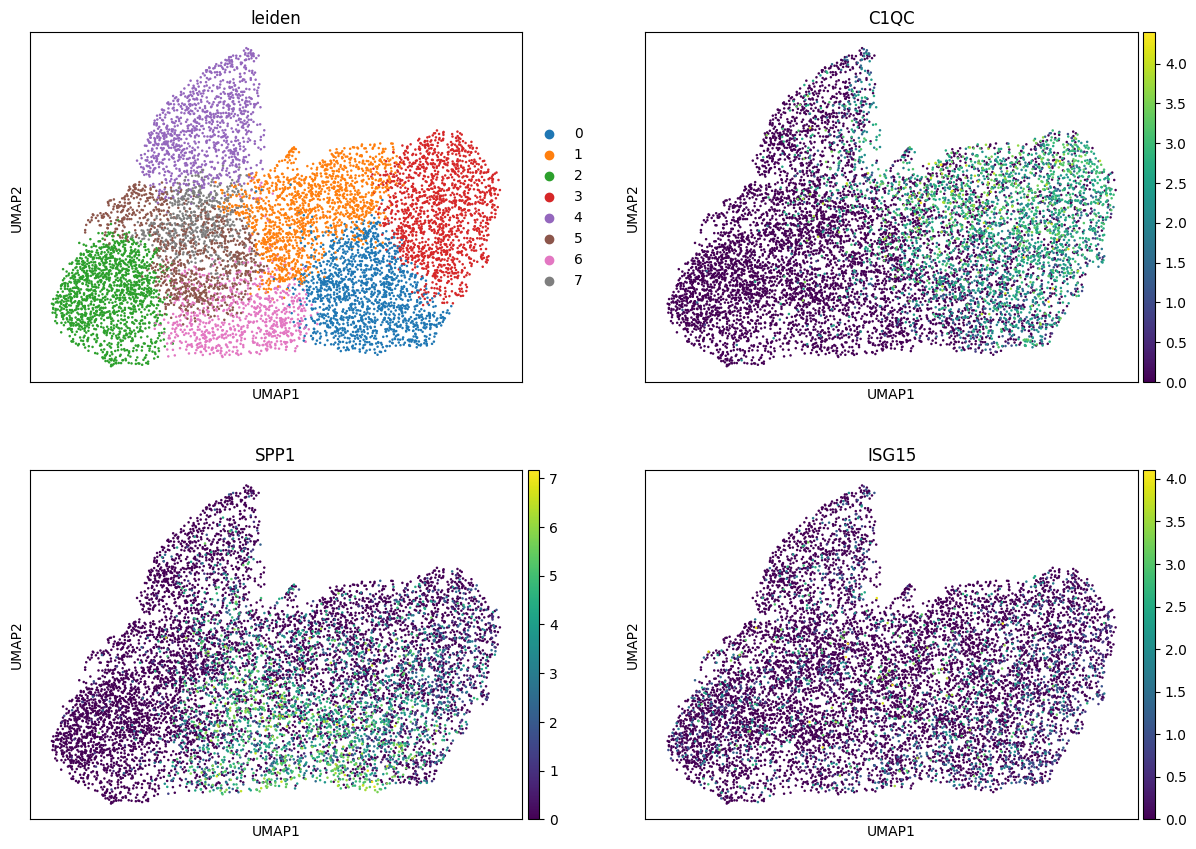

In [15]:
sc.pl.umap(mac, color=['leiden', 'C1QC', 'SPP1', 'ISG15'], ncols=2, use_raw=True)

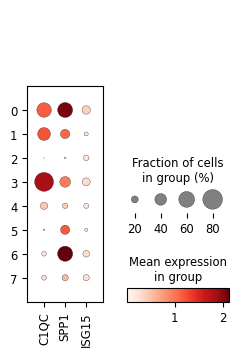

In [16]:
sc.pl.dotplot(mac, ['C1QC', 'SPP1', 'ISG15'], groupby='leiden', use_raw=True)

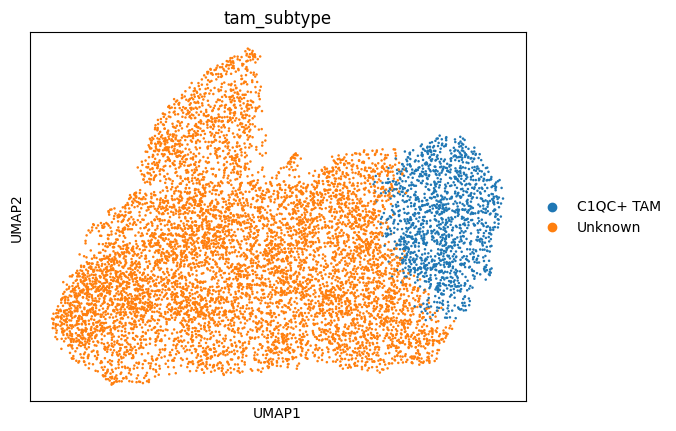

In [17]:
mac.obs['tam_subtype'] = mac.obs['leiden'].map({
    '3': 'C1QC+ TAM',
}).fillna('Unknown')

sc.pl.umap(mac, color='tam_subtype')